In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
device = "cuda"
torch.manual_seed(27)

### Data for modulo addition for prime P

In [2]:
p = 97
a = torch.arange(p).repeat_interleave(p)
b = torch.arange(p).repeat(p)
eq = torch.full_like(a, p)
X = torch.stack([a, b, eq], dim=1)
y = (a + b) % p

## Class Implementation of Various Architectures from Scratch

In [3]:
class Attention(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.W_q = nn.Linear(embedding_dim, embedding_dim)
        self.W_k = nn.Linear(embedding_dim, embedding_dim)
        self.W_v = nn.Linear(embedding_dim, embedding_dim)

    def forward(self, x):
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
    
        attn_map = torch.matmul(Q, K.transpose(-2, -1))
        intermediate = attn_map / self.embedding_dim ** 0.5
        out = torch.matmul(torch.softmax(intermediate, dim=-1), V)

        return out

In [4]:
class MLP(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.fc1 = nn.Linear(embedding_dim, 4 * embedding_dim)
        self.fc2 = nn.Linear(4 * embedding_dim, embedding_dim)                            
    def forward(self, x):
        L1 = self.fc1(x)
        L2 = F.gelu(L1)
        L3 = self.fc2(L2)

        return L3

## Full Transformer Method

In [5]:
class Transformer(nn.Module):
    def __init__(self, vocab_size, embedding_dim, seq_len):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embedding_dim)
        self.pos_emb   = nn.Embedding(seq_len, embedding_dim)
        self.attention = Attention(embedding_dim)
        self.mlp       = MLP(embedding_dim)
        self.unembed   = nn.Linear(embedding_dim, vocab_size)

    def forward(self, x):
        positions = torch.arange(x.shape[1], device=x.device)
        h = self.token_emb(x) + self.pos_emb(positions)
        h = h + self.attention(h)
        h = h + self.mlp(h)
        logits = self.unembed(h)

        return logits[:, -1, :]

### Train / Test split

In [6]:
# generate random indices of the dataset size
perm = torch.randperm(p * p)
n_train = int(0.3 * p * p)

# first 30% and rest of indices
train_idx = perm[:n_train]
test_idx  = perm[n_train:]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

X_train, y_train = X_train.to(device), y_train.to(device)
X_test,  y_test  = X_test.to(device),  y_test.to(device)

## Training Loop

In [7]:
model = Transformer(vocab_size=98, embedding_dim=128, seq_len=3).to(device)                 
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(),
                              lr=1e-3, weight_decay=1.0)
train_accuracies = []
test_accuracies = []

for epoch in range(50_000):
    model.train()
    logits = model(X_train)         
    loss = loss_fn(logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        model.eval()
        with torch.no_grad():
            test_logits = model(X_test)
            train_acc = (logits.argmax(-1) == y_train).float().mean()
            test_acc  = (test_logits.argmax(-1) == y_test).float().mean()
        train_accuracies.append(train_acc.item())
        test_accuracies.append(test_acc.item())

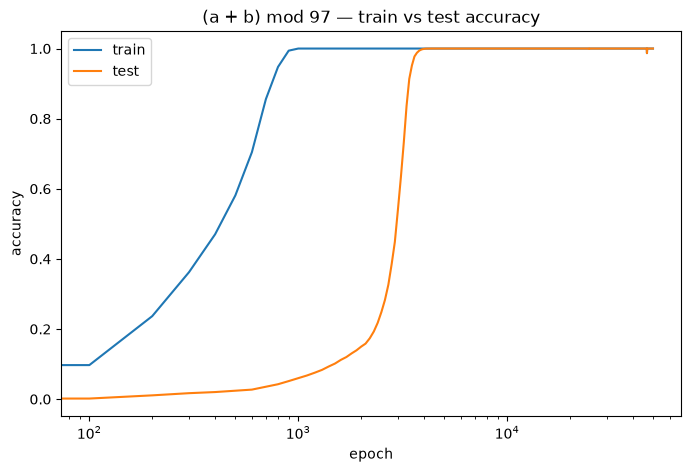

In [8]:
epochs_logged = [i * 100 for i in range(len(train_accuracies))]
plt.figure(figsize=(8, 5))
plt.plot(epochs_logged, train_accuracies, label="train")
plt.plot(epochs_logged, test_accuracies, label="test")
plt.xscale("log")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("(a + b) mod 97 — train vs test accuracy")
plt.legend()
plt.savefig("grokking_curve.png", dpi=150, bbox_inches="tight")
plt.show()